**Logistic regression model for heart dataset**

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

**load the dataset**

In [2]:
path ="/content/drive/MyDrive/Data Science Datasets/heart.csv"

In [3]:
heart = pd.read_csv(path)

**Display First five records**

In [4]:
heart.head(5)

,age,sex,cp,restbps,chol,fbs,restecg,maxheartRate,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


**Display last five records**

In [5]:
heart.tail(5)

,age,sex,cp,restbps,chol,fbs,restecg,maxheartRate,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


**Observation**

*   The libraries have been imported successfully.
*   The dataset has been loaded correctly.

*   The first and last five records have been displayed and they look good.
  





**check the shape**

In [6]:
heart.shape

(303, 14)

Observation - The dataset has 303 records and 14 columns

**Check the datatypes**

In [7]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           303 non-null    int64  
 1   sex           303 non-null    int64  
 2   cp            303 non-null    int64  
 3   restbps       303 non-null    int64  
 4   chol          303 non-null    int64  
 5   fbs           303 non-null    int64  
 6   restecg       303 non-null    int64  
 7   maxheartRate  303 non-null    int64  
 8   exang         303 non-null    int64  
 9   oldpeak       303 non-null    float64
 10  slope         303 non-null    int64  
 11  ca            303 non-null    int64  
 12  thal          303 non-null    int64  
 13  target        303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


**Observation**

The dataset has 2 datatypes where 13 columns that are of integer type and one column which is float type.

**check statistical summaries**

In [8]:
heart.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.37,9.08,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.68,0.47,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.97,1.03,0.0,0.0,1.0,2.0,3.0
restbps,303.0,131.62,17.54,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.26,51.83,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.15,0.36,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.53,0.53,0.0,0.0,1.0,1.0,2.0
maxheartRate,303.0,149.65,22.91,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.33,0.47,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.04,1.16,0.0,0.0,0.8,1.6,6.2


**Observations**

*   The mean age is 54.37 and the average age is 55 thus there is no variabilty and the distribution is normal, minimum age is 29 and maximum age is 77.

*  The mean maxheartRate 149.65 and average is 153.0, min.maxheartRate is 71.0 and maximum is 202.0 ,there is variability and is left skewed thus not normal



* The mean chol is 246.26 and average is 240.0 , minimum chol is 126.9 and maximum is 564.0 there is variability and is a right  skew  thus not normal
* The mean restbps is 131.62 and average is 130.0, minimum restbps is 94.0 and maximum is 200.0 , thus no variabilty and normal distribution.





**check correlations**

In [9]:
corr= heart.corr()
corr.round(4)

,age,sex,cp,restbps,chol,fbs,restecg,maxheartRate,exang,oldpeak,slope,ca,thal,target
age,1.0000,-0.0984,-0.0687,0.2794,0.2137,0.1213,-0.1162,-0.3985,0.0968,0.2100,-0.1688,0.2763,0.0680,-0.2254
sex,-0.0984,1.0000,-0.0494,-0.0568,-0.1979,0.0450,-0.0582,-0.0440,0.1417,0.0961,-0.0307,0.1183,0.2100,-0.2809
cp,-0.0687,-0.0494,1.0000,0.0476,-0.0769,0.0944,0.0444,0.2958,-0.3943,-0.1492,0.1197,-0.1811,-0.1617,0.4338
restbps,0.2794,-0.0568,0.0476,1.0000,0.1232,0.1775,-0.1141,-0.0467,0.0676,0.1932,-0.1215,0.1014,0.0622,-0.1449
chol,0.2137,-0.1979,-0.0769,0.1232,1.0000,0.0133,-0.1510,-0.0099,0.0670,0.0540,-0.0040,0.0705,0.0988,-0.0852
fbs,0.1213,0.0450,0.0944,0.1775,0.0133,1.0000,-0.0842,-0.0086,0.0257,0.0057,-0.0599,0.1380,-0.0320,-0.0280
restecg,-0.1162,-0.0582,0.0444,-0.1141,-0.1510,-0.0842,1.0000,0.0441,-0.0707,-0.0588,0.0930,-0.0720,-0.0120,0.1372
maxheartRate,-0.3985,-0.0440,0.2958,-0.0467,-0.0099,-0.0086,0.0441,1.0000,-0.3788,-0.3442,0.3868,-0.2132,-0.0964,0.4217
exang,0.0968,0.1417,-0.3943,0.0676,0.0670,0.0257,-0.0707,-0.3788,1.0000,0.2882,-0.2577,0.1157,0.2068,-0.4368
oldpeak,0.2100,0.0961,-0.1492,0.1932,0.0540,0.0057,-0.0588,-0.3442,0.2882,1.0000,-0.5775,0.2227,0.2102,-0.4307


**correlation heatmap**

<Axes: >

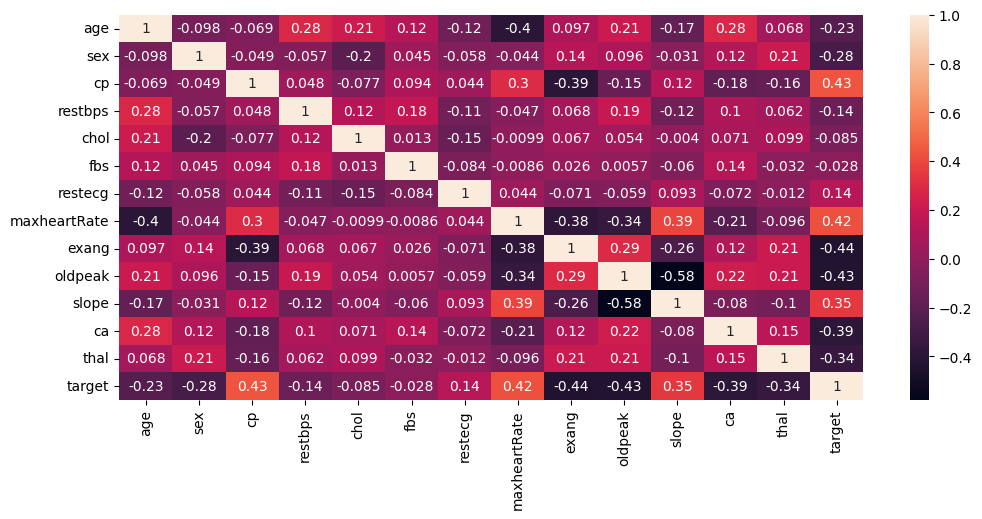

In [10]:
plt.figure(figsize=(12,5))
sns.heatmap(corr, annot=True)


**Age distribution**

Text(0.5, 1.0, 'Age Distribution')

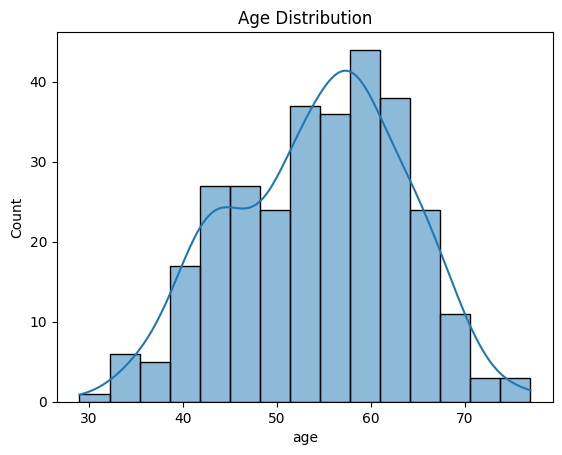

In [62]:
sns.histplot( data=heart, x='age', kde=True, bins=15 )
plt.title("Age Distribution")

**Observation**

- This is the age distribution of a middle-aged to older adult group, centered in the late 50s / early 60s, with very few young adults (<35) and very few elderly people (>75).



**Histogram of age distribution by heart disease**

Text(0.5, 1.0, 'Age Distribution by Heart Disease')

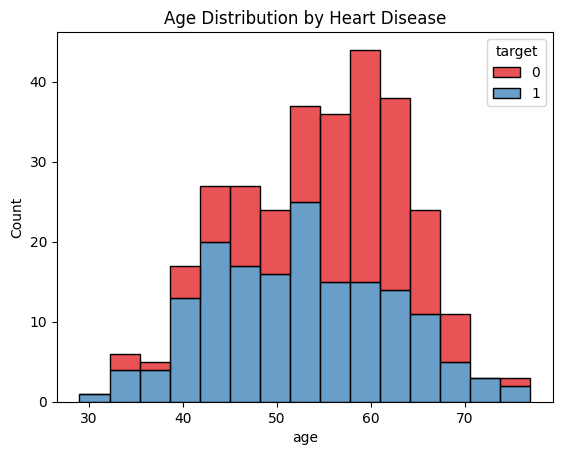

In [63]:
sns.histplot( data=heart, x='age', hue='target', multiple='stack', bins=15, palette='Set1' )
plt.title("Age Distribution by Heart Disease")

**Observations**

- Heart disease diagnosis is surprisingly common in the younger subset of this group (30s-early 50s), but becomes less relatively common in the oldest ages shown



**Scatter plot of maxhheartRate and age**

Text(0.5, 1.0, 'Age vs Max Heart Rate Achieved colored by Target')

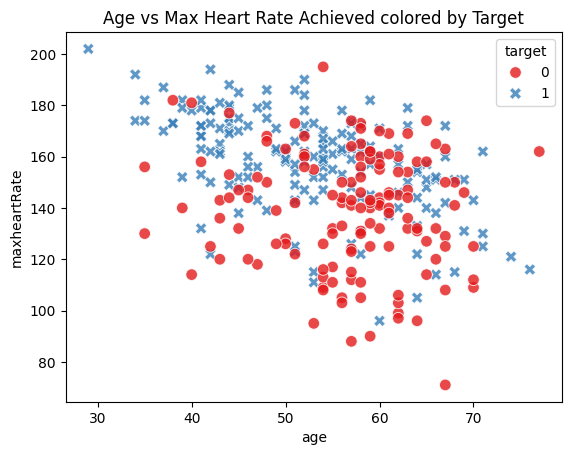

In [60]:
sns.scatterplot(data=heart, x='age', y='maxheartRate', hue='target',
                style='target', palette='Set1', alpha=0.8, s=70)
plt.title("Age vs Max Heart Rate Achieved colored by Target")

**Observations**



1.   max heart rate decreases strongly with age

2.   people with heart disease reach systematically lower peak heart rates than healthy people of the same age





**Pairplot for some columns**

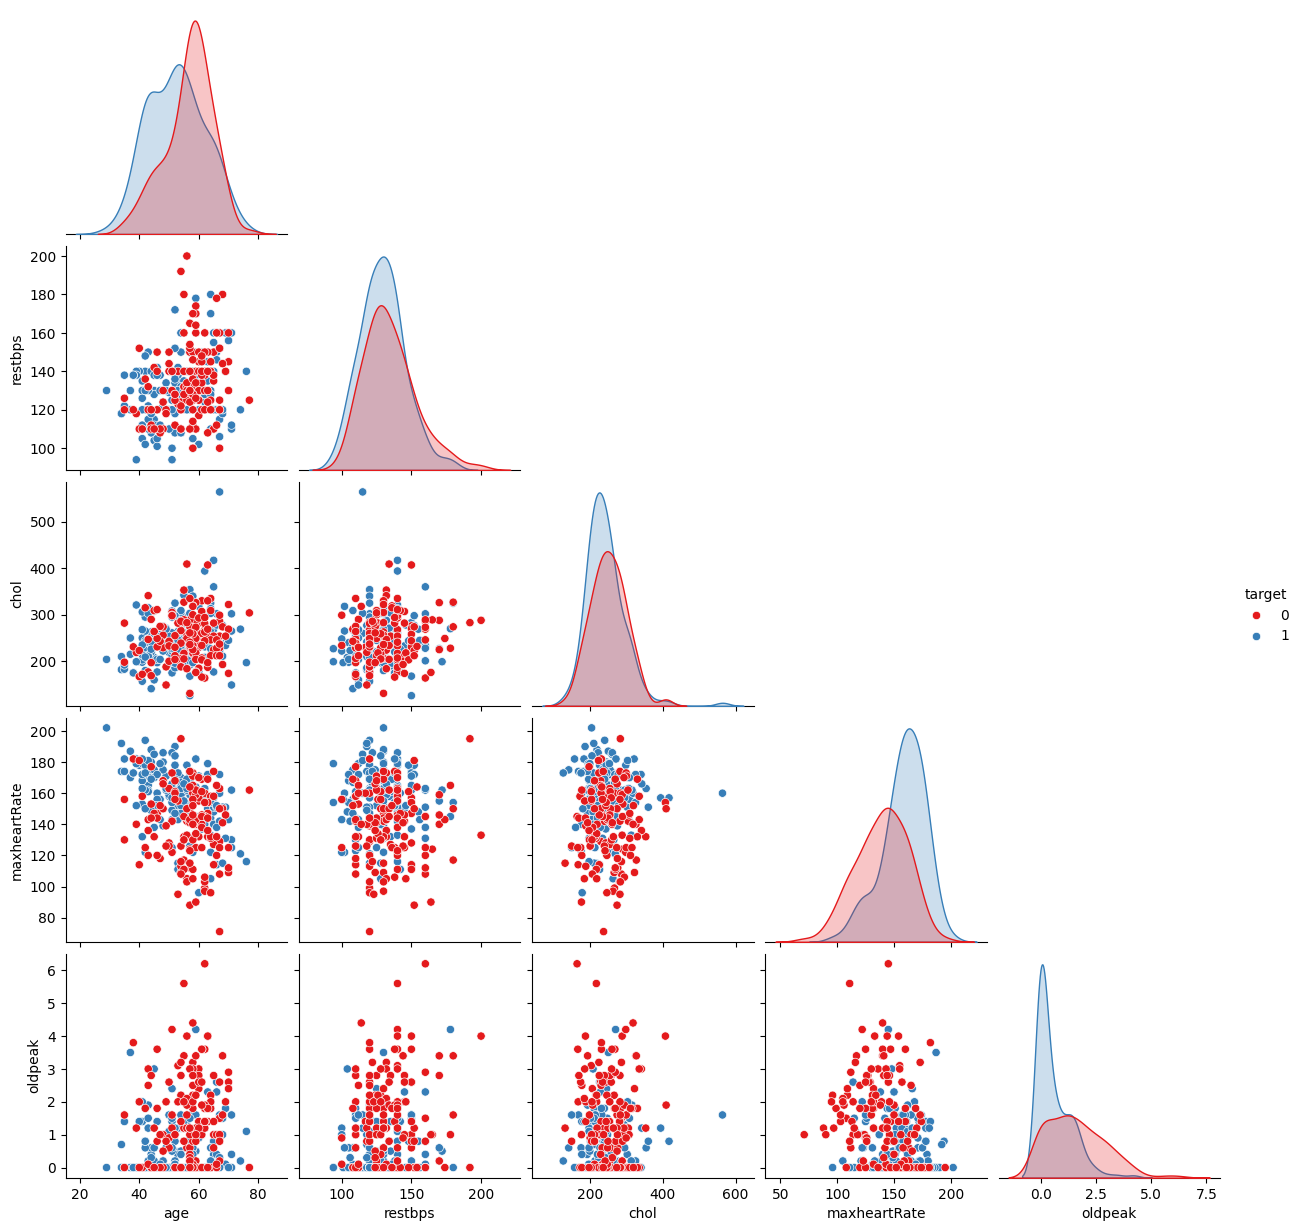

In [64]:
num_cols = ['age', 'restbps', 'chol', 'maxheartRate', 'oldpeak']
sns.pairplot(heart[num_cols + ['target']],
             hue='target', palette='Set1',
             corner=True, diag_kind='kde')
plt.show()

**convert "?" to NaN**

In [11]:
heart.replace('?', np.nan, inplace=True)

**check for missing values**

In [12]:
heart.isnull().sum()

,0
age,0
sex,0
cp,0
restbps,0
chol,0
fbs,0
restecg,0
maxheartRate,0
exang,0
oldpeak,0


**Observation :** There are no missing values in the dataset

**check for outliers**

<Axes: >

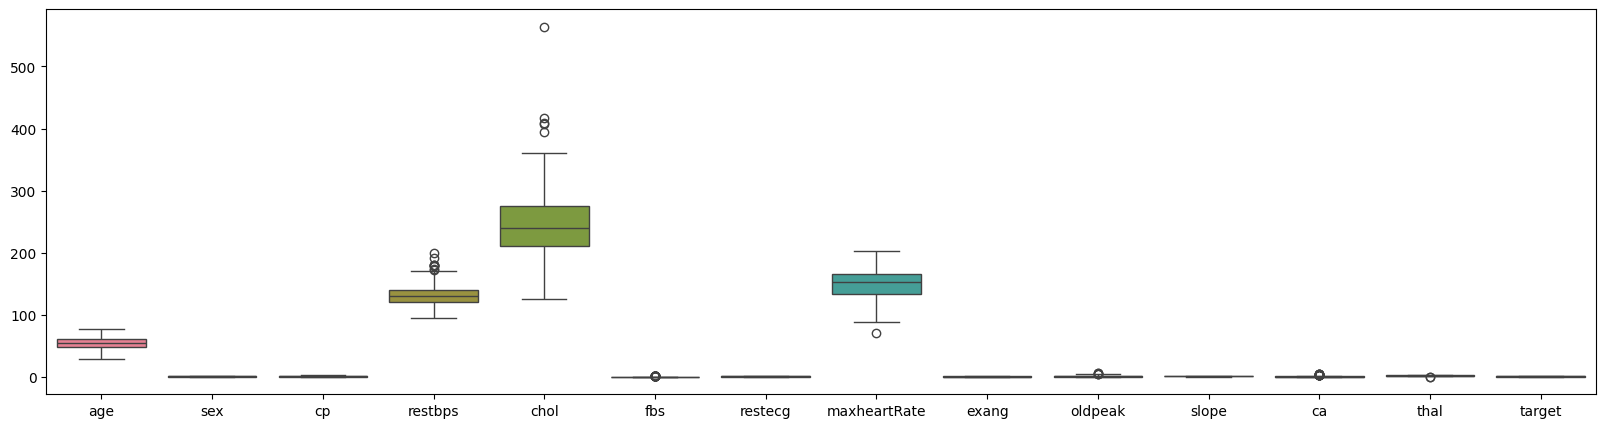

In [13]:
plt.figure(figsize=(20,5))
sns.boxplot(data=heart)

**Observation**

columns , ('restbps','chol','fbs','maxheartRate','oldpeak','ca','thal') have oultiers that needed to be treated

<Axes: ylabel='restbps'>

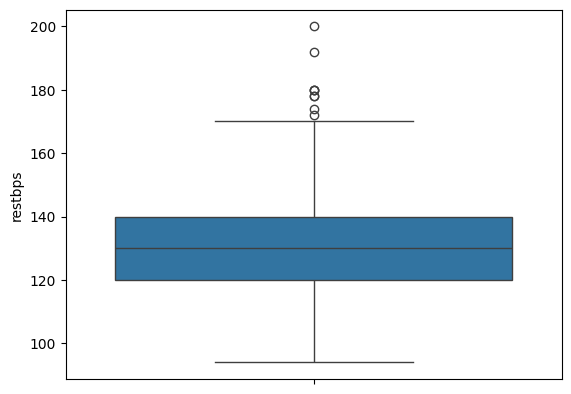

In [14]:
sns.boxplot(heart['restbps'])

<Axes: ylabel='chol'>

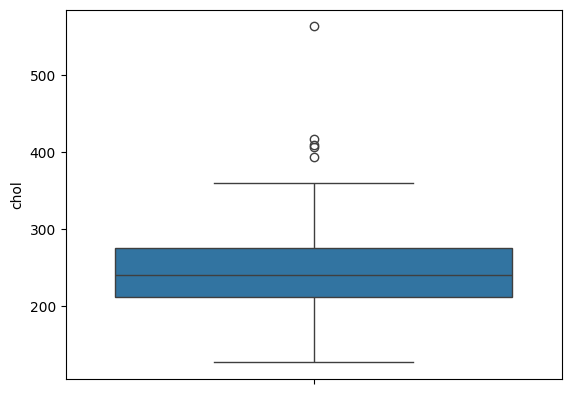

In [51]:
sns.boxplot(heart['chol'])

<Axes: ylabel='ca'>

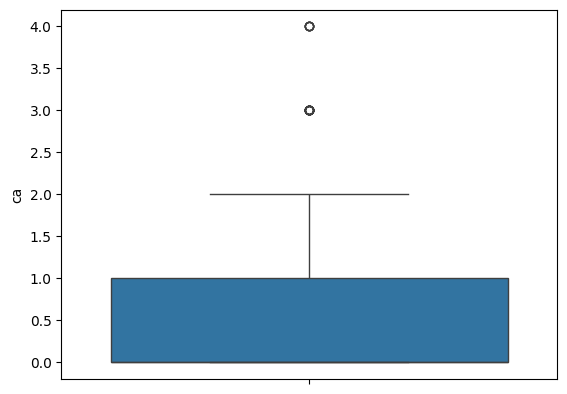

In [54]:
sns.boxplot(heart['ca'])

<Axes: ylabel='thal'>

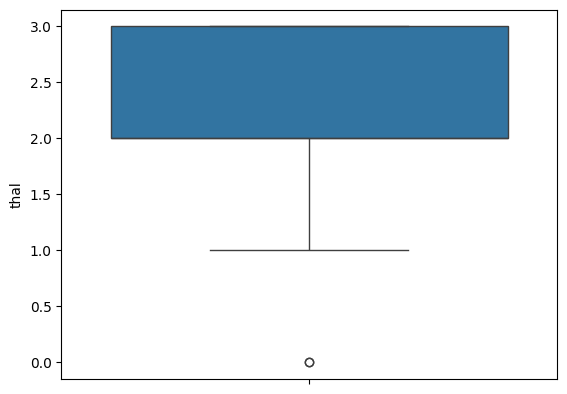

In [55]:
sns.boxplot(heart['thal'])

**Treatment of outliers**

In [15]:
Q1= heart.quantile(0.25)
Q3= heart.quantile(0.75)
IQR= Q3-Q1

In [16]:
new_heart= heart[~((heart<(Q1-1.5*IQR)) | (heart>(Q3+1.5*IQR))).any(axis=1)]

In [17]:
print("New dataset after outlier removal", new_heart.shape)


New dataset after outlier removal (228, 14)


**Observation**

- The new dataset has 228 records and 14 columns

<Axes: >

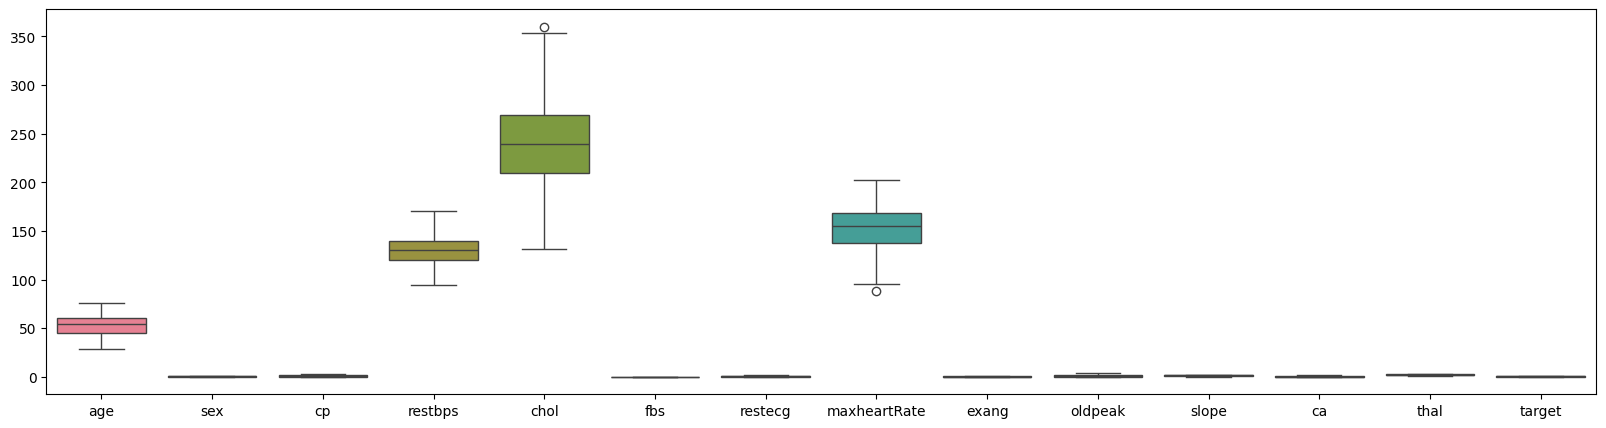

In [18]:
plt.figure(figsize=(20,5))
sns.boxplot(data=new_heart)

**create dummy variables**

columns that need dummy variables include;

*   cp(Chestpain type)- Types 0, 1, 2, and 3
*   restecg(Resting ECG)- Results (0, 1, 2) are different diagnostic states.


*   slope(Peak Exercise ST Segment)- Represents the shape (upsloping, flat, downsloping)
*   thal (Thallium Stress Test)-Represents scan results (Normal, Fixed, Reversible)





In [19]:
from sklearn.preprocessing import OneHotEncoder

In [20]:
encoder = OneHotEncoder(sparse_output=False, drop= 'first').set_output(transform="pandas")
data= new_heart[['cp', 'restecg', 'slope', 'thal']]
encoded_data = encoder.fit_transform(data)
heart_df = pd.concat([new_heart.drop(['cp', 'restecg', 'slope', 'thal'],axis=1), encoded_data], axis=1)

**Display First five records**

In [21]:
heart_df.head(5)

,age,sex,restbps,chol,fbs,maxheartRate,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_2,thal_3
1,37,1,130,250,0,187,0,3.5,0,1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,41,0,130,204,0,172,0,1.4,0,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,56,1,120,236,0,178,0,0.8,0,1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
4,57,0,120,354,0,163,1,0.6,0,1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
5,57,1,140,192,0,148,0,0.4,0,1,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


**Display las t five records**

In [50]:
heart_df.tail(5)

,age,sex,restbps,chol,fbs,maxheartRate,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_2,thal_3
296,63,0,124,197,0,136,1,0.0,0,0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
298,57,0,140,241,0,123,1,0.2,0,0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
299,45,1,110,264,0,132,0,1.2,0,0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
301,57,1,130,131,0,115,1,1.2,1,0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
302,57,0,130,236,0,174,0,0.0,1,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [23]:
heart_df.shape

(228, 19)

**Observation**

The new dataset has 228 records and 19 columns, an addition of 6 new columns resulting from creating dummy variables.

**splitting data for modelling**

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X = heart_df.drop('target', axis=1)
y = heart_df['target']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**check the distribution of splits**

In [28]:
display(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(182, 18)

(46, 18)

(182,)

(46,)

**standardize data for modelling**

In [29]:
from sklearn.preprocessing import StandardScaler

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Import  logistic regression model and metrics**

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [32]:

lr = LogisticRegression()
#fit model with data
lr.fit(X_train_scaled, y_train)

LogisticRegression()

**Get the coefficients**

In [43]:
lr.coef_

array([[ 0.17744455, -0.76960097, -0.19330837, -0.22066684,  0.        ,
         0.39776438, -0.19012367, -0.60430417, -0.94847447,  0.1631189 ,
         0.50846562,  0.46444878,  0.13019931, -0.03072066, -0.15836619,
         0.33244856,  0.03601199, -0.98127039]])

In [47]:
for  i, col in enumerate(X_train.columns):
  print("The coeffficient for {} is {} ".format(col, lr.coef_[0][i]))

The coeffficient for age is 0.17744455482287036 
The coeffficient for sex is -0.7696009737420085 
The coeffficient for restbps is -0.19330836975715182 
The coeffficient for chol is -0.22066683544531152 
The coeffficient for fbs is 0.0 
The coeffficient for maxheartRate is 0.3977643779077039 
The coeffficient for exang is -0.1901236692963032 
The coeffficient for oldpeak is -0.6043041707854904 
The coeffficient for ca is -0.9484744739020038 
The coeffficient for cp_1 is 0.1631188994490342 
The coeffficient for cp_2 is 0.5084656221287116 
The coeffficient for cp_3 is 0.46444878364397263 
The coeffficient for restecg_1 is 0.13019931025052045 
The coeffficient for restecg_2 is -0.030720658453616025 
The coeffficient for slope_1 is -0.1583661918500783 
The coeffficient for slope_2 is 0.3324485632894683 
The coeffficient for thal_2 is 0.036011991105778164 
The coeffficient for thal_3 is -0.9812703942435573 


**predict with test data**

In [33]:
y_pred = lr.predict(X_test_scaled)

In [34]:
y_pred

array([1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 1])

**Model Evaluation**

**Confusion matrix**

In [35]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[12,  9],
       [ 0, 25]])

**plot confusion matrix**

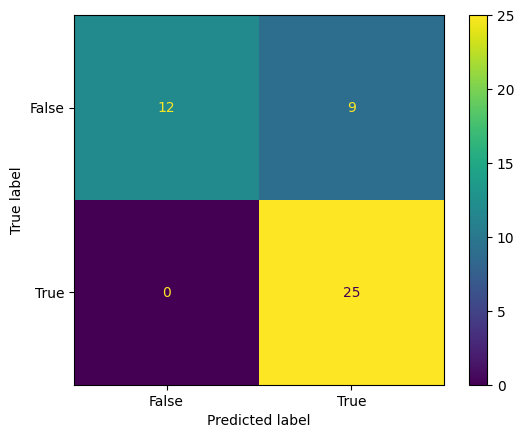

In [36]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cnf_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

**metrics to be computed**


1.   Accuracy - how often the model is correct
2.   Precision - of the positives predicted, which percent is truly positive


1.   Sensitivity - True postives and false negatives that have been predicted correctly
2.   Specificity - how good model is at predicting negative results


1.   F_score - harmonic mean of precision and senstivity










**Accuracy**

(True Positive + True negative)/Total Predictions

In [37]:
Accuracy = metrics.accuracy_score(y_test, y_pred)
print("Our model accuracy is : ", Accuracy)

Our model accuracy is :  0.8043478260869565


**Precision**

True Postive/(True Positive + True Negative)


In [38]:
Precision = metrics.precision_score(y_test, y_pred)
print("Our model precision is : ", Precision)

Our model precision is :  0.7352941176470589


**Senstivity**

True Positive/(True Positive + False negative)

In [39]:
Sensitivity = metrics.recall_score(y_test, y_pred)
print("Our model sensitivity is : ", Sensitivity)


Our model sensitivity is :  1.0


**Specifity**

True negative/(True negative + False Positive)

In [40]:
Specificity = metrics.recall_score(y_test, y_pred, pos_label=0)
print("Our model specificity is : ", Specificity)

Our model specificity is :  0.5714285714285714


**f1- score**

((Precision*Sensitivity)/(Precision+Sensitivity))

In [41]:
F1_score = metrics.f1_score(y_test, y_pred)
print("Our model f1-score is : ", F1_score)

Our model f1-score is :  0.847457627118644


**Interpretation**



1.   Accuracy: 80.4%
-  Overall, the model correctly predicts ~80% of all cases (both diseased and healthy).


2. Precision (Positive Predictive Value): 73.5%
- When the model predicts heart disease (positive class), it is correct only ~73.5% of the time.
- Quite a few false positives exist — about 26-27% of the "disease" predictions are actually healthy people.


3.   Sensitivity / Recall : 100%
- The model detected every single actual heart disease case in the test set (no false negatives).
- Extremely strong at finding people who truly have heart disease.


4.  Specificity / True Negative Rate: 57.1%
-  Only 57% of the healthy people are correctly identified as healthy.
-  Many healthy people are incorrectly classified as having heart disease (43% false positive rate among healthy cases).




5.  F1-score (positive class): 84.7%
-  The very high recall (1.0) pulls the F1 up significantly, even though precision is only moderate.







  



**Observations**



1.   Very high sensitivity (100%)
- This is the strongest point of the model. It is excellent at identifying people who actually have heart disease — it missed none of the true cases in the test set.
-  Very valuable in medical screening / early detection contexts where missing a sick person (false negative) is very costly.


2.  Moderate-to-low specificity (57%)
-  The model flags many healthy people as potentially diseased
-  leads to many false alarms.


3.  Precision is noticeably lower than recall

- This limits its usefulness as a stand-alone diagnostic tool — it would generate too many unnecessary follow-up tests / anxiety.


4.   Imbalanced performance pattern
-  Extremely good at detecting positives (sensitivity = 1.0)  
- Not good  at ruling out disease (specificity ≈ 57%)
- This is a classic high-recall / lower-specificity trade-off — very common when  The dataset is somewhat imbalanced toward the negative class



5.   Overall suitability
-  Good as a screening tool ( don't miss anyone sick)  
- Not great as a confirmatory / diagnostic tool (too many false positives)  
- this kind of model would likely be used as a first-stage filter, followed by more specific tests for the people it flags as positive.









